# Convolutional Neural Networks

A **convolutional neural network (CNN)** is a neural network designed for data with spatial structure, especially images. The key idea is to learn small filters that scan across the image and detect local patterns.

In this notebook, we use PyTorch to classify handwritten digits from the built-in `sklearn` digits dataset. The images are small, so the full notebook runs quickly without downloading MNIST.


> *A CNN never memorizes where the cat sits --- it learns the whiskers once, then looks for them everywhere.* --- Words of wisdom by Claude Fable 5 (2026)


## What Is a CNN?

A CNN is built around <span style="color:lightblue">filters</span>. A filter is a small grid of learned weights, such as a $3\times 3$ kernel. The same filter slides across the whole image, producing a <span style="color:pink">feature map</span> that marks where the pattern appears.

This is different from a fully connected network. A fully connected layer treats every pixel position as a separate input. A convolution layer reuses the same weights at many locations, so it can learn a pattern once and look for it everywhere.


## How It Works

1. **Convolution.** Learn several small filters and slide them across the image.
2. **Activation.** Apply a nonlinear function such as ReLU so the model can learn nonlinear patterns.
3. **Pooling.** Downsample each feature map, keeping the strongest local signals and reducing image size.
4. **Stack and repeat.** Early layers detect simple patterns; later layers combine them into more useful shapes.
5. **Flatten.** Turn the final feature maps into one vector.
6. **Classify.** Feed that vector into a small MLP-style classifier to predict the digit label.
7. **Train.** Use cross-entropy loss and backpropagation to update all filter and classifier weights.


## Why It Works

Images have local structure. Nearby pixels often belong to the same stroke, edge, texture, or object part. CNNs use that fact in two ways:

- **Locality:** each filter looks at a small neighborhood, not the whole image at once.
- **Parameter sharing:** the same filter is reused across locations, so the model can detect the same pattern in different parts of the image.

For handwritten digits, a CNN can learn small stroke patterns first, then combine them into digit-level evidence.


## Pros and Cons

**Pros**

- Learns visual features automatically.
- Uses far fewer parameters than a fully connected network on raw pixels.
- Handles small shifts better because filters are reused across locations.
- Gives useful diagnostic views: filters, feature maps, confusion matrix, and misclassified images.

**Cons**

- Still needs labeled examples.
- Has several design choices: kernel size, channel count, pooling, learning rate, and epochs.
- Less directly interpretable than a small decision tree or linear model.
- Larger CNNs may require GPUs and careful regularization.


## Setup

The plotting helper below makes the notebook usable in two environments: if `matplotlib` is installed, the cells draw figures; if not, they print compact numerical summaries so the PyTorch path can still be validated.


In [1]:
import random

import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
print("matplotlib available:", plt is not None)

palette = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]


device: cpu
matplotlib available: True


## Load and Prepare the Digits

The `sklearn` digits dataset contains 8-by-8 grayscale images. Pixel values range from 0 to 16, so we divide by 16 to put them on a 0-to-1 scale. PyTorch convolution layers expect image tensors shaped like `[batch, channels, height, width]`, so each digit becomes `[1, 8, 8]`.


In [2]:
digits = load_digits()
X_images = digits.images.astype("float32") / 16.0
y_labels = digits.target.astype("int64")

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_images, y_labels, test_size=0.20, random_state=seed, stratify=y_labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=seed, stratify=y_train_full
)

# Add the channel dimension: [N, 8, 8] -> [N, 1, 8, 8].
X_train_t = torch.tensor(X_train[:, None, :, :], dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val[:, None, :, :], dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test[:, None, :, :], dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

batch_size = 64
generator = torch.Generator().manual_seed(seed)
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True,
    generator=generator,
)

print(f"training images:   {len(X_train)}")
print(f"validation images: {len(X_val)}")
print(f"test images:       {len(X_test)}")
print(f"image shape:       {X_train_t.shape[1:]}")


training images:   1149
validation images: 288
test images:       360
image shape:       torch.Size([1, 8, 8])


## Visualize the Input Images

Before training a CNN, look at the data. The model sees each image as a matrix of pixel intensities.


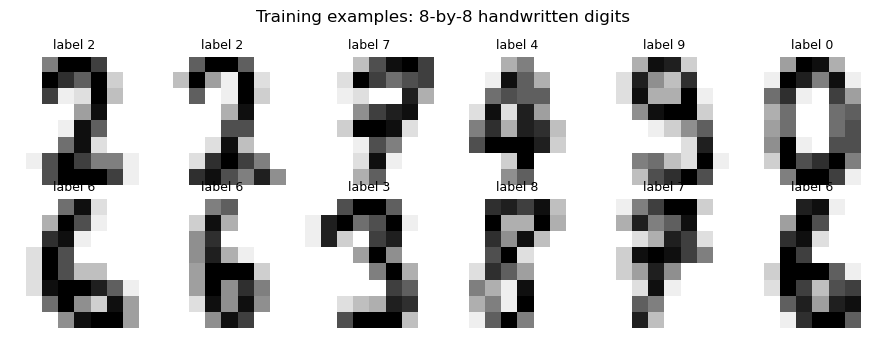

In [3]:
def show_digit_grid(images, labels, n=12, title="Sample digits"):
    if plt is None:
        print(title)
        for i in range(min(n, len(images))):
            print(f"label={labels[i]}")
            print(np.round(images[i], 2))
            print()
        return

    cols = 6
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.7))
    axes = np.array(axes).reshape(-1)
    for ax, image, label in zip(axes, images[:n], labels[:n]):
        ax.imshow(image, cmap="gray_r", vmin=0, vmax=1)
        ax.set_title(f"label {label}", fontsize=9)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_digit_grid(X_train, y_train, n=12, title="Training examples: 8-by-8 handwritten digits")


## A Single Convolution Filter

Before using learned filters, it helps to see one hand-written filter. The vertical-edge kernel below responds when nearby pixels change strongly from left to right.


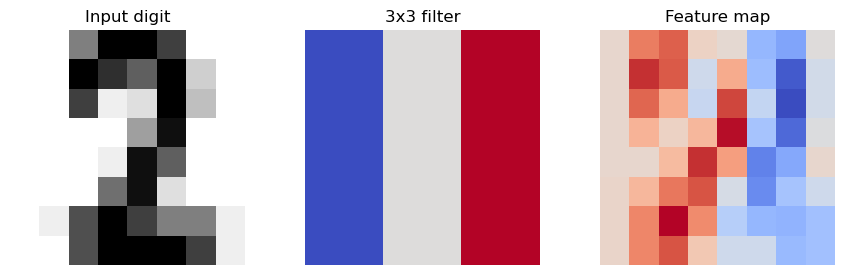

In [4]:
import torch.nn.functional as F

example_image = torch.tensor(X_train[0], dtype=torch.float32)
vertical_edge_kernel = torch.tensor(
    [[-1.0, 0.0, 1.0],
     [-1.0, 0.0, 1.0],
     [-1.0, 0.0, 1.0]],
    dtype=torch.float32,
)

# conv2d expects [batch, channels, height, width] for the image and
# [out_channels, in_channels, kernel_height, kernel_width] for the filter.
filtered = F.conv2d(
    example_image.view(1, 1, 8, 8),
    vertical_edge_kernel.view(1, 1, 3, 3),
    padding=1,
).squeeze().numpy()

if plt is None:
    print("input image matrix:")
    print(np.round(example_image.numpy(), 2))
    print("vertical edge kernel:")
    print(vertical_edge_kernel.numpy())
    print("filtered output:")
    print(np.round(filtered, 2))
else:
    fig, axes = plt.subplots(1, 3, figsize=(9, 2.8))
    axes[0].imshow(example_image.numpy(), cmap="gray_r", vmin=0, vmax=1)
    axes[0].set_title("Input digit")
    axes[1].imshow(vertical_edge_kernel.numpy(), cmap="coolwarm")
    axes[1].set_title("3x3 filter")
    axes[2].imshow(filtered, cmap="coolwarm")
    axes[2].set_title("Feature map")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## Define the CNN

This is a small CNN for small images. The comments in `forward` show the shape changes. Shape tracking is one of the best ways to debug CNN code.


In [5]:
class SmallDigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),  # [B, 1, 8, 8] -> [B, 8, 8, 8]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                # [B, 8, 8, 8] -> [B, 8, 4, 4]
            nn.Conv2d(8, 16, kernel_size=3, padding=1), # [B, 8, 4, 4] -> [B, 16, 4, 4]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                # [B, 16, 4, 4] -> [B, 16, 2, 2]
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 2 * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        feature_maps = self.features(x)
        logits = self.classifier(feature_maps)
        return logits

cnn = SmallDigitCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(cnn)
print(f"trainable parameters: {count_parameters(cnn):,}")


SmallDigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)
trainable parameters: 3,658


## Train and Validate

For classification, the model outputs one score for each digit class. Cross-entropy loss rewards the correct class score being higher than the others. The validation set tells us whether training progress is generalizing beyond the training mini-batches.


In [6]:
num_epochs = 30
best_val_acc = 0.0
best_state = None
history = []

for epoch in range(1, num_epochs + 1):
    cnn.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()       # clear old gradients
        logits = cnn(xb)            # forward pass
        loss = loss_fn(logits, yb)  # cross-entropy loss
        loss.backward()             # backpropagation
        optimizer.step()            # update filters and classifier weights

        running_loss += loss.item() * len(xb)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += len(xb)

    train_loss = running_loss / total
    train_acc = correct / total

    cnn.eval()
    with torch.no_grad():
        val_logits = cnn(X_val_t)
        val_loss = loss_fn(val_logits, y_val_t).item()
        val_acc = (val_logits.argmax(dim=1) == y_val_t).float().mean().item()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {name: value.detach().clone() for name, value in cnn.state_dict().items()}

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"epoch {epoch:02d} | train loss {train_loss:.3f} | "
            f"train acc {train_acc:.3f} | val acc {val_acc:.3f}"
        )

if best_state is not None:
    cnn.load_state_dict(best_state)


epoch 01 | train loss 2.303 | train acc 0.101 | val acc 0.101
epoch 05 | train loss 1.942 | train acc 0.546 | val acc 0.552
epoch 10 | train loss 0.736 | train acc 0.794 | val acc 0.812
epoch 15 | train loss 0.434 | train acc 0.876 | val acc 0.858
epoch 20 | train loss 0.307 | train acc 0.916 | val acc 0.899
epoch 25 | train loss 0.244 | train acc 0.927 | val acc 0.920
epoch 30 | train loss 0.180 | train acc 0.947 | val acc 0.938


## Training Curve

The training curve is a quick diagnostic. We want training accuracy to rise, but we also want validation accuracy to rise. If training accuracy rises while validation accuracy falls, the model is overfitting.


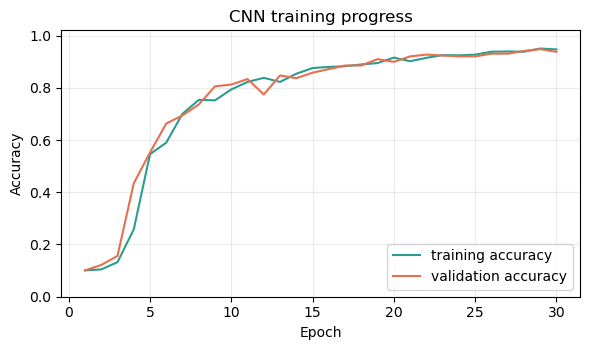

In [7]:
epochs = [row["epoch"] for row in history]
train_acc = [row["train_acc"] for row in history]
val_acc = [row["val_acc"] for row in history]

if plt is None:
    print("final training accuracy:", round(train_acc[-1], 3))
    print("best validation accuracy:", round(max(val_acc), 3))
else:
    plt.figure(figsize=(6, 3.6))
    plt.plot(epochs, train_acc, color=palette[1], label="training accuracy")
    plt.plot(epochs, val_acc, color=palette[4], label="validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.02)
    plt.title("CNN training progress")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Test Performance and Confusion Matrix

The test set is used once, after training. The confusion matrix shows which digits the model tends to confuse.


test accuracy: 0.922
confusion matrix:
[[35  0  0  0  1  0  0  0  0  0]
 [ 0 26  3  2  0  1  1  0  2  1]
 [ 0  0 34  0  0  0  0  0  1  0]
 [ 0  0  1 36  0  0  0  0  0  0]
 [ 0  1  0  0 35  0  0  0  0  0]
 [ 0  0  0  0  0 36  0  0  1  0]
 [ 0  1  0  0  1  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  4  1  0  1  0  0  0 29  0]
 [ 0  0  0  0  3  1  0  1  0 31]]


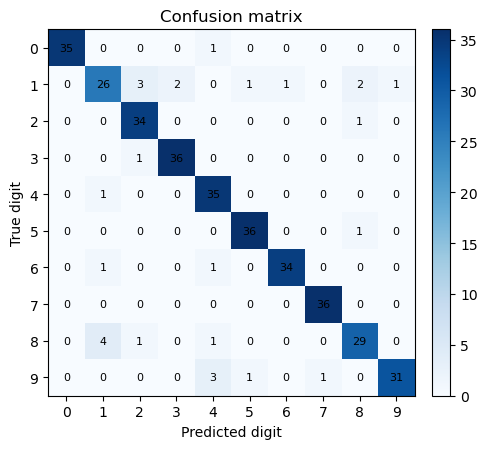

In [8]:
cnn.eval()
with torch.no_grad():
    test_logits = cnn(X_test_t)
    test_pred = test_logits.argmax(dim=1).cpu().numpy()

test_acc = accuracy_score(y_test, test_pred)
cm = confusion_matrix(y_test, test_pred)
print(f"test accuracy: {test_acc:.3f}")
print("confusion matrix:")
print(cm)

if plt is not None:
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    image = ax.imshow(cm, cmap="Blues")
    ax.set_title("Confusion matrix")
    ax.set_xlabel("Predicted digit")
    ax.set_ylabel("True digit")
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


## Inspect Mistakes

Accuracy is one number. Looking at mistakes tells us what kind of errors the model makes. This is often more useful for teaching than a slightly better score.


number of test mistakes: 28 out of 360


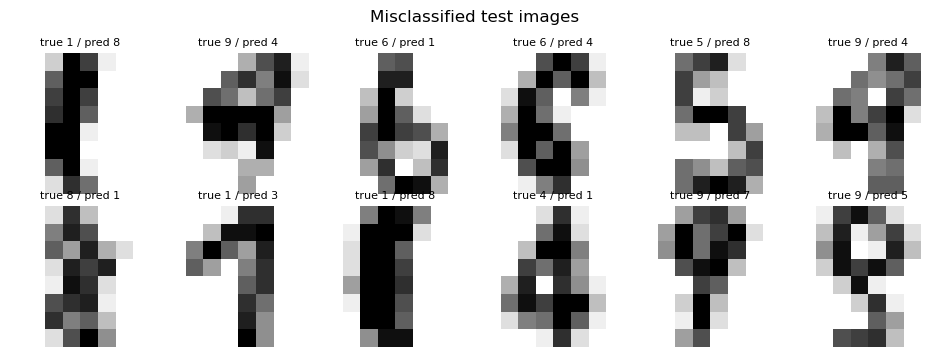

In [9]:
wrong_indices = np.flatnonzero(test_pred != y_test)
print(f"number of test mistakes: {len(wrong_indices)} out of {len(y_test)}")

if len(wrong_indices) == 0:
    print("No mistakes found.")
elif plt is None:
    for idx in wrong_indices[:8]:
        print(f"true={y_test[idx]}, predicted={test_pred[idx]}")
        print(np.round(X_test[idx], 2))
        print()
else:
    n = min(12, len(wrong_indices))
    cols = 6
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, wrong_indices[:n]):
        ax.imshow(X_test[idx], cmap="gray_r", vmin=0, vmax=1)
        ax.set_title(f"true {y_test[idx]} / pred {test_pred[idx]}", fontsize=8)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("Misclassified test images")
    plt.tight_layout()
    plt.show()


## Feature Maps

Feature maps show what the convolution layers produce for one image. Early feature maps often highlight strokes, edges, or local intensity patterns.


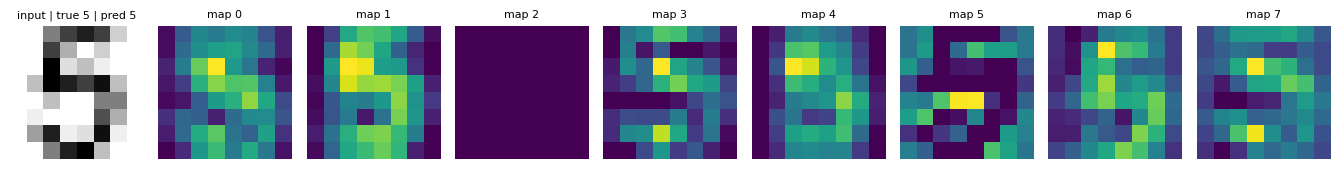

In [10]:
def show_first_layer_feature_maps(model, image, true_label):
    model.eval()
    x = torch.tensor(image[None, None, :, :], dtype=torch.float32).to(device)

    with torch.no_grad():
        first_conv = model.features[0](x)
        activated = model.features[1](first_conv).cpu().squeeze(0).numpy()
        pred = model(x).argmax(dim=1).item()

    if plt is None:
        print(f"true={true_label}, predicted={pred}, feature map tensor shape={activated.shape}")
        print("first feature map:")
        print(np.round(activated[0], 2))
        return

    n_maps = min(8, activated.shape[0])
    fig, axes = plt.subplots(1, n_maps + 1, figsize=(1.5 * (n_maps + 1), 1.8))
    axes[0].imshow(image, cmap="gray_r", vmin=0, vmax=1)
    axes[0].set_title(f"input | true {true_label} | pred {pred}", fontsize=8)
    axes[0].axis("off")
    for k in range(n_maps):
        axes[k + 1].imshow(activated[k], cmap="viridis")
        axes[k + 1].set_title(f"map {k}", fontsize=8)
        axes[k + 1].axis("off")
    plt.tight_layout()
    plt.show()

show_first_layer_feature_maps(cnn, X_test[0], y_test[0])


## Takeaway

A CNN is useful when the input has spatial structure. The convolution layers learn local filters; pooling compresses the representation; the classifier reads the final feature maps.

For students, the most important debugging questions are:

- Are the tensor shapes correct?
- Is the model using convolution before flattening?
- Does validation accuracy improve along with training accuracy?
- Do the mistakes make visual sense?
